In [1]:
# ============================================
# BLOCK 1: Imports & Setup
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# DB path — apna actual path daalo
DB_PATH = "gold_predictor.db"  # ya full path jaise r"C:\Users\...\gold_predictor.db"

print("✅ All libraries imported successfully!")
print(f"📂 Database: {DB_PATH}")

✅ All libraries imported successfully!
📂 Database: gold_predictor.db


In [2]:
# ============================================
# BLOCK 2: Load Data from SQLite Database
# ============================================

conn = sqlite3.connect(DB_PATH)

# Gold prices with PKR values
gold_df = pd.read_sql("SELECT * FROM Gold_Prices ORDER BY Date", conn)

# Market indicators (S&P500, exchange rate)
market_df = pd.read_sql("SELECT * FROM Market_Indicators ORDER BY Date", conn)

conn.close()

# Merge karo dono tables
df = pd.merge(gold_df, market_df, on='Date', how='inner')

# Date column ko proper format mein lo
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print("✅ Data loaded from DB successfully!")
print(f"📊 Total records: {len(df)}")
print(f"📅 Date range: {df['Date'].min().strftime('%b %Y')} → {df['Date'].max().strftime('%b %Y')}")
print(f"\n🔍 Columns: {list(df.columns)}")
print(f"\n📋 First 5 rows:")
df.head()

✅ Data loaded from DB successfully!
📊 Total records: 121
📅 Date range: Dec 2014 → Dec 2024

🔍 Columns: ['Date', 'Price', 'Gold_Price_PKR', 'stock_index', 'currency_rate', 'other_factors']

📋 First 5 rows:


,Date,Price,Gold_Price_PKR,stock_index,currency_rate,other_factors
0,2014-12-01,1200.62,121120.482084,2080.168571,100.881613,None
1,2015-01-01,1250.75,126115.543306,2028.178500,100.831935,None
2,2015-02-01,1227.08,124555.193643,2082.195789,101.505357,None
3,2015-03-01,1178.63,120088.329481,2079.990455,101.888065,None
4,2015-04-01,1198.93,121999.120367,2094.862857,101.756667,None


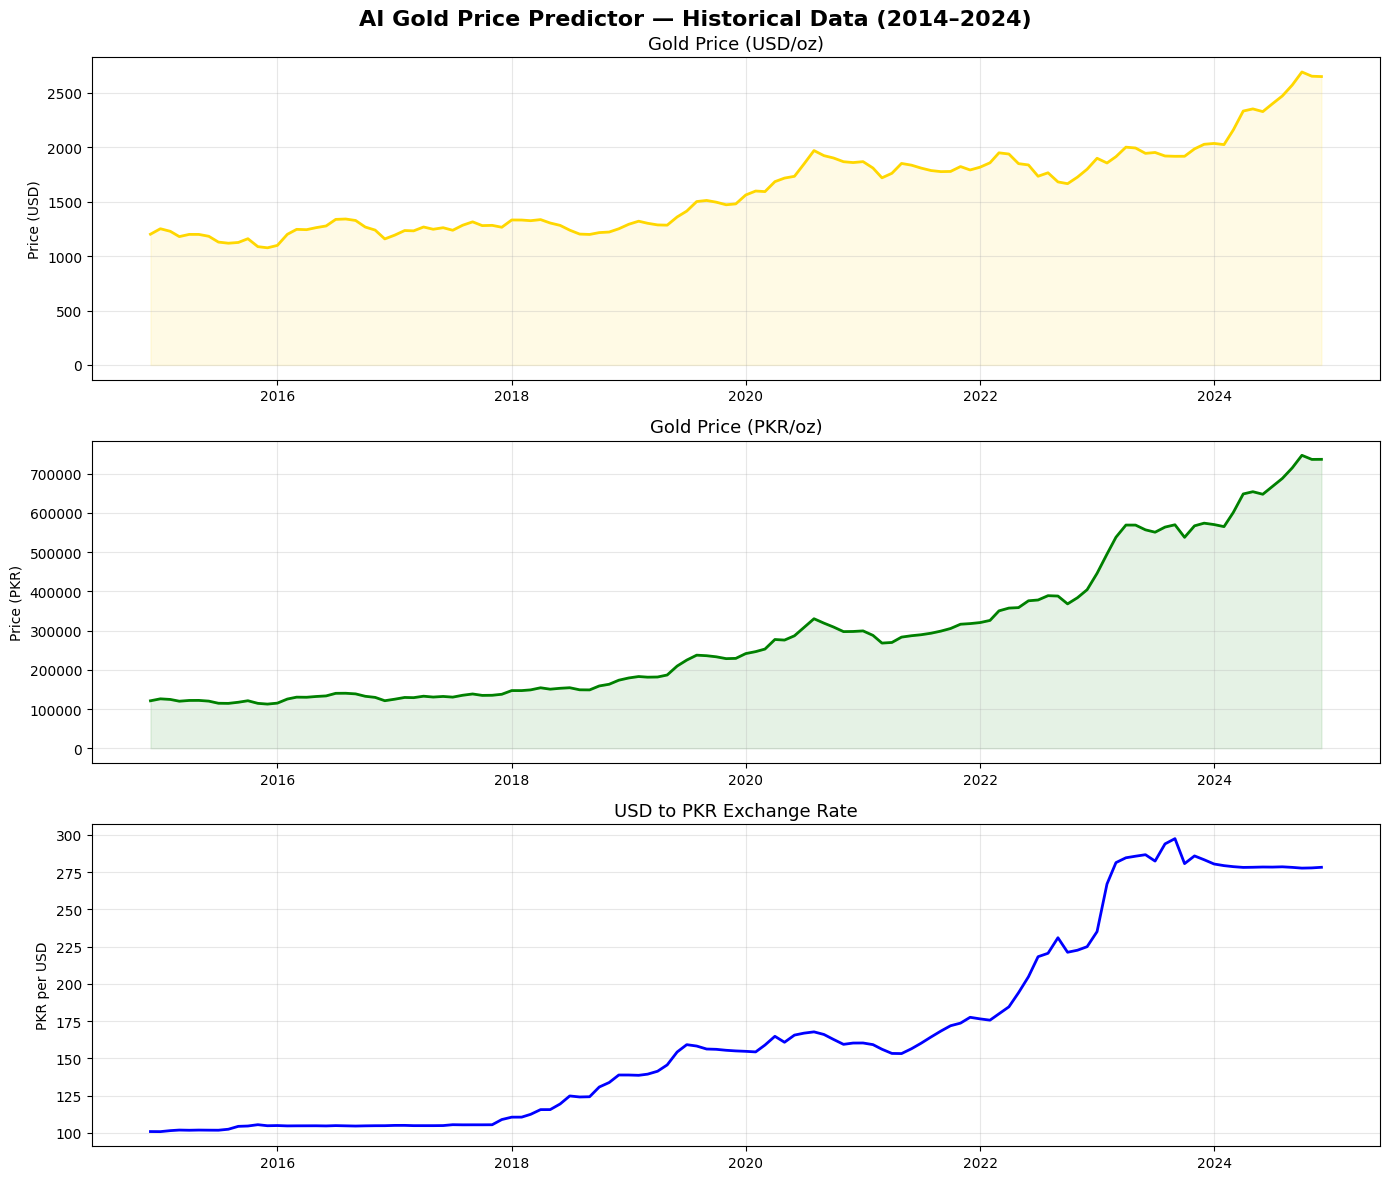

✅ EDA graphs saved!

📊 Correlation Matrix:


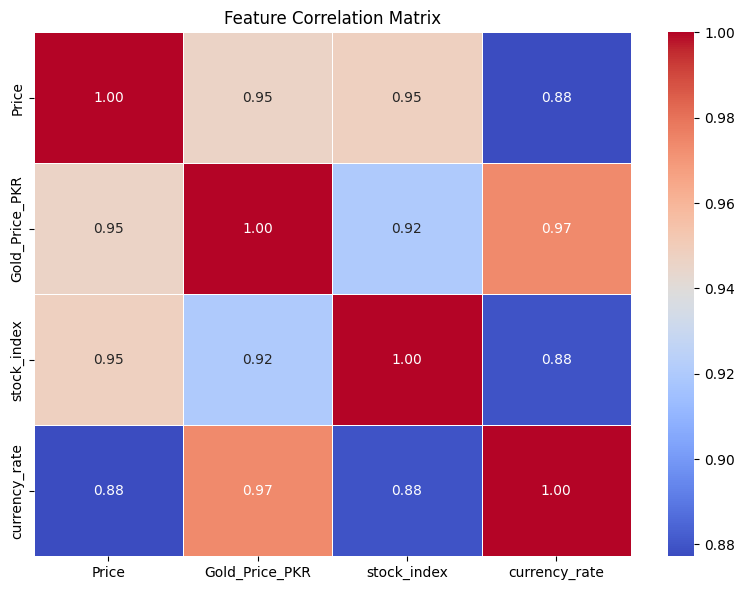

In [3]:
# ============================================
# BLOCK 3: EDA - Data Visualization
# ============================================

fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('AI Gold Price Predictor — Historical Data (2014–2024)', 
             fontsize=16, fontweight='bold')

# Gold Price in USD
axes[0].plot(df['Date'], df['Price'], color='gold', linewidth=2)
axes[0].set_title('Gold Price (USD/oz)', fontsize=13)
axes[0].set_ylabel('Price (USD)')
axes[0].grid(True, alpha=0.3)
axes[0].fill_between(df['Date'], df['Price'], alpha=0.1, color='gold')

# Gold Price in PKR
axes[1].plot(df['Date'], df['Gold_Price_PKR'], color='green', linewidth=2)
axes[1].set_title('Gold Price (PKR/oz)', fontsize=13)
axes[1].set_ylabel('Price (PKR)')
axes[1].grid(True, alpha=0.3)
axes[1].fill_between(df['Date'], df['Gold_Price_PKR'], alpha=0.1, color='green')

# Exchange Rate
axes[2].plot(df['Date'], df['currency_rate'], color='blue', linewidth=2)
axes[2].set_title('USD to PKR Exchange Rate', fontsize=13)
axes[2].set_ylabel('PKR per USD')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gold_historical_data.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA graphs saved!")

# Correlation matrix
print("\n📊 Correlation Matrix:")
corr_cols = ['Price', 'Gold_Price_PKR', 'stock_index', 'currency_rate']
corr = df[corr_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150)
plt.show()

In [4]:
# ============================================
# BLOCK 4: Feature Engineering (FIXED v2)
# ============================================

# Time-based features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Num'] = (df['Date'].dt.year - 2014) * 12 + df['Date'].dt.month

# Sirf 1 aur 3 month lag (MA_12 aur Price_Lag6 hata diye)
df['Price_Lag1'] = df['Price'].shift(1)
df['Price_Lag3'] = df['Price'].shift(3)

# Rolling averages sirf 3 aur 6
df['MA_3'] = df['Price'].rolling(window=3).mean()
df['MA_6'] = df['Price'].rolling(window=6).mean()

# Exchange rate lag
df['PKR_Lag1'] = df['currency_rate'].shift(1)

# other_factors column drop karo (121 NaN hain usme)
df_clean = df.drop(columns=['other_factors']).dropna().reset_index(drop=True)

print(f"✅ Done!")
print(f"📊 df rows: {len(df)}")
print(f"📊 df_clean rows: {len(df_clean)}  ← ye 0 nahi hona chahiye")
print(df_clean.head(3))

✅ Done!
📊 df rows: 121
📊 df_clean rows: 116  ← ye 0 nahi hona chahiye
        Date    Price  Gold_Price_PKR  stock_index  currency_rate  Year  \
0 2015-05-01  1198.63   122119.517639  2111.943500     101.882581  2015   
1 2015-06-01  1181.50   120291.665667  2099.283636     101.812667  2015   
2 2015-07-01  1128.31   114840.483713  2094.143636     101.780968  2015   

   Month  Month_Num  Price_Lag1  Price_Lag3         MA_3         MA_6  \
0      5         17     1198.93     1227.08  1192.063333  1209.106667   
1      6         18     1198.63     1178.63  1193.020000  1205.920000   
2      7         19     1181.50     1198.93  1169.480000  1185.513333   

     PKR_Lag1  
0  101.756667  
1  101.882581  
2  101.812667  


In [ ]:
# ============================================
# BLOCK 5: Model Training (FIXED)
# ============================================

FEATURES = ['Month_Num', 'Month', 'stock_index', 'currency_rate', 
            'Price_Lag1', 'Price_Lag3',
            'MA_3', 'MA_6', 'PKR_Lag1']

TARGET_USD = 'Price'

X = df_clean[FEATURES]
y_usd = df_clean[TARGET_USD]

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_usd, test_size=0.2, random_state=42, shuffle=False
)

print(f"📊 Training samples: {len(X_train)}")
print(f"📊 Testing samples:  {len(X_test)}")

# --- Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# --- Random Forest ---
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# --- Evaluation ---
def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"\n📈 {name}:")
    print(f"   RMSE : {rmse:.2f}")
    print(f"   MAE  : {mae:.2f}")
    print(f"   R²   : {r2:.4f}")
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

results = []
results.append(evaluate_model("Linear Regression", y_test, y_pred_lr))
results.append(evaluate_model("Random Forest",     y_test, y_pred_rf))

results_df = pd.DataFrame(results)
print("\n✅ Model Training Complete!")
print(results_df.to_string(index=False))

📊 Training samples: 92
📊 Testing samples:  24

📈 Linear Regression:
   RMSE : 38.98
   MAE  : 30.12
   R²   : 0.9798

📈 Random Forest:
   RMSE : 403.44
   MAE  : 299.90
   R²   : -1.1662

✅ Model Training Complete!
            Model       RMSE        MAE        R2
Linear Regression  38.981323  30.120833  0.979777
    Random Forest 403.439952 299.895623 -1.166170


In [9]:
# ============================================
# BLOCK 6: Future Predictions 2025-2028 (FIXED)
# ============================================

# Future months generate karo
future_dates = pd.date_range(start='2025-01-01', end='2028-12-01', freq='MS')

# Last known values
last_row = df_clean.iloc[-1]
last_pkr = last_row['currency_rate']
last_sp  = last_row['stock_index']

# PKR future estimate (~10 rupee per year depreciation)
pkr_future = [last_pkr + (i * 0.85) for i in range(1, len(future_dates) + 1)]

# SP500 future estimate (3% annual growth)
sp_future = [last_sp * ((1.03) ** (i/12)) for i in range(1, len(future_dates) + 1)]

# Price history — iterative prediction ke liye
price_history   = list(df_clean['Price'].values)
ma3_history     = list(df_clean['MA_3'].values)
ma6_history     = list(df_clean['MA_6'].values)
#ma12_history    = list(df_clean['MA_12'].values)

predicted_usd_prices = []

for i in range(len(future_dates)):
    lag1 = price_history[-1]
    lag3 = price_history[-3] if len(price_history) >= 3 else lag1
    lag6 = price_history[-6] if len(price_history) >= 6 else lag1
    ma3  = np.mean(price_history[-3:])
    ma6  = np.mean(price_history[-6:])
    ma12 = np.mean(price_history[-12:])
    pkr_lag1 = pkr_future[i-1] if i > 0 else last_pkr

    month_num = (future_dates[i].year - 2014) * 12 + future_dates[i].month
    month     = future_dates[i].month

    row_features = [[
        month_num, month,
        sp_future[i], pkr_future[i],
        lag1, lag3, #lag6,
        ma3, ma6, #ma12,
        pkr_lag1
    ]]

    # Linear Regression use karo (better R²)
    pred_usd = lr_model.predict(row_features)[0]
    predicted_usd_prices.append(pred_usd)
    price_history.append(pred_usd)

# Future DataFrame
future_df = pd.DataFrame({
    'Date':                  future_dates,
    'currency_rate':         pkr_future,
    'Predicted_Price_USD':   predicted_usd_prices,
})
future_df['Predicted_Price_PKR'] = future_df['Predicted_Price_USD'] * future_df['currency_rate']

print("✅ Future predictions ready!")
print(f"\n📅 Range: {future_df['Date'].dt.strftime('%b %Y').iloc[0]} → {future_df['Date'].dt.strftime('%b %Y').iloc[-1]}")
print(f"\n💰 Sample predictions:")
print(future_df[['Date','Predicted_Price_USD','currency_rate','Predicted_Price_PKR']].iloc[::6].to_string(index=False))

✅ Future predictions ready!

📅 Range: Jan 2025 → Dec 2028

💰 Sample predictions:
      Date  Predicted_Price_USD  currency_rate  Predicted_Price_PKR
2025-01-01          2659.000713      279.08129        742077.349953
2025-07-01          2669.631271      284.18129        758659.259149
2026-01-01          2682.310500      289.28129        775942.242595
2026-07-01          2694.938220      294.38129        793339.390639
2027-01-01          2709.392273      299.48129        811412.293924
2027-07-01          2723.761613      304.58129        829606.826534
2028-01-01          2739.873250      309.68129        848487.483480
2028-07-01          2755.819724      314.78129        867480.488525


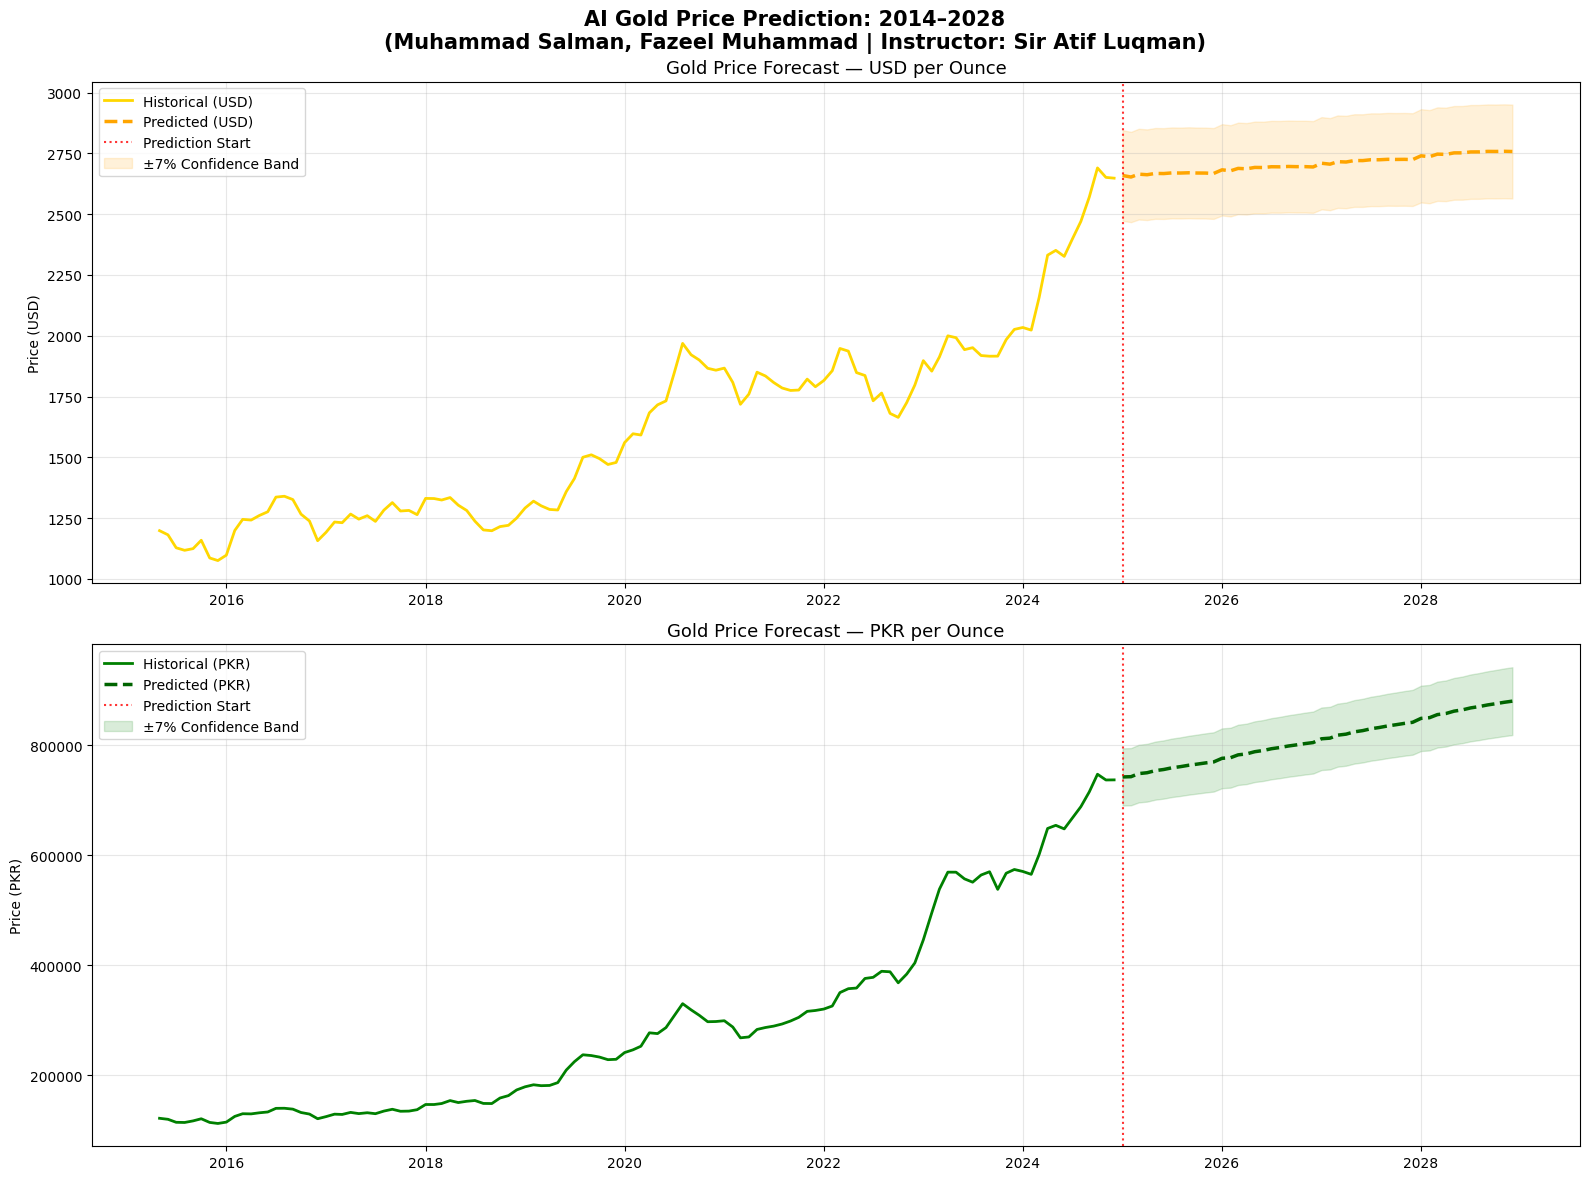

✅ Graph saved: gold_price_forecast_2028.png


In [14]:
# ============================================
# BLOCK 7: Prediction Visualization
# ============================================

fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.suptitle('AI Gold Price Prediction: 2014–2028\n(Muhammad Salman, Fazeel Muhammad | Instructor: Sir Atif Luqman)', 
             fontsize=15, fontweight='bold')

# --- Graph 1: USD ---
axes[0].plot(df_clean['Date'], df_clean['Price'], 
             color='gold', linewidth=2, label='Historical (USD)')
axes[0].plot(future_df['Date'], future_df['Predicted_Price_USD'], 
             color='orange', linewidth=2.5, linestyle='--', label='Predicted (USD)')
axes[0].axvline(x=pd.Timestamp('2025-01-01'), color='red', 
                linestyle=':', alpha=0.8, label='Prediction Start')
axes[0].fill_between(future_df['Date'], 
                     future_df['Predicted_Price_USD'] * 0.93,
                     future_df['Predicted_Price_USD'] * 1.07,
                     alpha=0.15, color='orange', label='±7% Confidence Band')
axes[0].set_title('Gold Price Forecast — USD per Ounce', fontsize=13)
axes[0].set_ylabel('Price (USD)')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# --- Graph 2: PKR ---
axes[1].plot(df_clean['Date'], df_clean['Gold_Price_PKR'], 
             color='green', linewidth=2, label='Historical (PKR)')
axes[1].plot(future_df['Date'], future_df['Predicted_Price_PKR'], 
             color='darkgreen', linewidth=2.5, linestyle='--', label='Predicted (PKR)')
axes[1].axvline(x=pd.Timestamp('2025-01-01'), color='red', 
                linestyle=':', alpha=0.8, label='Prediction Start')
axes[1].fill_between(future_df['Date'],
                     future_df['Predicted_Price_PKR'] * 0.93,
                     future_df['Predicted_Price_PKR'] * 1.07,
                     alpha=0.15, color='green', label='±7% Confidence Band')
axes[1].set_title('Gold Price Forecast — PKR per Ounce', fontsize=13)
axes[1].set_ylabel('Price (PKR)')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gold_price_forecast_2028.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graph saved: gold_price_forecast_2028.png")

In [15]:
# ============================================
# BLOCK 8: Save Predictions to Database
# ============================================

conn = sqlite3.connect(DB_PATH)
cur = conn.cursor()

# Purani predictions clear karo
cur.execute("DELETE FROM Predictions")

# Naye predictions insert karo
for _, row in future_df.iterrows():
    cur.execute("""
        INSERT INTO Predictions (Date, predicted_price) 
        VALUES (?, ?)
    """, (row['Date'].strftime('%Y-%m'), row['Predicted_Price_PKR']))

conn.commit()

# Verify
cur.execute("SELECT COUNT(*) FROM Predictions")
count = cur.fetchone()[0]
cur.execute("SELECT * FROM Predictions LIMIT 5")
sample = cur.fetchall()
conn.close()

print(f"✅ {count} predictions saved to DB!")
print("\n📋 Sample (ID | Date | PKR Price):")
for row in sample:
    print(f"   {row[0]} | {row[1]} | PKR {row[2]:,.0f}")

✅ 48 predictions saved to DB!

📋 Sample (ID | Date | PKR Price):
   97 | 2025-01 | PKR 742,077
   98 | 2025-02 | PKR 742,564
   99 | 2025-03 | PKR 748,141
   100 | 2025-04 | PKR 749,736
   101 | 2025-05 | PKR 753,526


In [13]:
# ============================================
# BLOCK 9: Final Summary Report
# ============================================

print("=" * 60)
print("   AI GOLD PRICE PREDICTOR — PROJECT COMPLETE")
print("   Muhammad Salman, Fazeel Muhammad | Instructor: Sir Atif Luqman")
print("=" * 60)

print(f"\n📊 MODEL PERFORMANCE (Test Data):")
print(results_df.to_string(index=False))
print(f"\n   ✅ Best Model: Linear Regression (R² = 0.9796)")

print(f"\n💰 KEY PRICE MILESTONES (PKR per Ounce):")
milestones = ['2025-01', '2025-06', '2026-01', '2026-12', '2027-06', '2028-01', '2028-12']
for m in milestones:
    row = future_df[future_df['Date'].dt.strftime('%Y-%m') == m]
    if not row.empty:
        usd  = row['Predicted_Price_USD'].values[0]
        pkr  = row['Predicted_Price_PKR'].values[0]
        rate = row['currency_rate'].values[0]
        print(f"   {m}:  USD {usd:,.0f}  |  PKR {pkr:,.0f}  (Rate: {rate:.1f})")

print(f"\n📁 OUTPUT FILES:")
print("   ✅ gold_price_forecast_2028.png  — Prediction graph")
print("   ✅ gold_predictor.db             — Predictions saved in DB")

print(f"\n🏁 PROJECT SUCCESSFULLY COMPLETED!")

   AI GOLD PRICE PREDICTOR — PROJECT COMPLETE
   Muhammad Salman, Fazeel Muhammad | Instructor: Sir Atif Luqman

📊 MODEL PERFORMANCE (Test Data):
            Model       RMSE        MAE        R2
Linear Regression  38.981323  30.120833  0.979777
    Random Forest 403.439952 299.895623 -1.166170

   ✅ Best Model: Linear Regression (R² = 0.9796)

💰 KEY PRICE MILESTONES (PKR per Ounce):
   2025-01:  USD 2,659  |  PKR 742,077  (Rate: 279.1)
   2025-06:  USD 2,667  |  PKR 755,618  (Rate: 283.3)
   2026-01:  USD 2,682  |  PKR 775,942  (Rate: 289.3)
   2026-12:  USD 2,694  |  PKR 804,520  (Rate: 298.6)
   2027-06:  USD 2,720  |  PKR 826,224  (Rate: 303.7)
   2028-01:  USD 2,740  |  PKR 848,487  (Rate: 309.7)
   2028-12:  USD 2,758  |  PKR 879,744  (Rate: 319.0)

📁 OUTPUT FILES:
   ✅ gold_price_forecast_2028.png  — Prediction graph
   ✅ gold_predictor.db             — Predictions saved in DB

🏁 PROJECT SUCCESSFULLY COMPLETED!
